# Kuvantunnistus omilla kuvilla - CNN

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, RandomFlip, RandomRotation, RandomZoom


batch_size = 32
img_size = (224, 224)
split_ratio = [0.7, 0.15, 0.15] 

# Ladataan datasetti
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "../datasets/kuvantunnistus",
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
)

# Normalisoidaan kuvat
dataset = dataset.map(lambda x, y: (x / 255.0, y))

dataset_size = len(dataset)


train_size = int(split_ratio[0] * dataset_size)
val_size = int(split_ratio[1] * dataset_size)

train_dataset = dataset.take(train_size)
validation_dataset = dataset.skip(train_size).take(val_size)
test_dataset = dataset.skip(train_size + val_size)


# Tarkistetaan datasetin koko
print(f"Train batches: {len(train_dataset)}, Validation batches: {len(validation_dataset)}, Test batches: {len(test_dataset)}")


2025-04-01 08:22:36.746629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743495756.907698     483 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743495756.953382     483 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743495757.397285     483 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743495757.397303     483 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1743495757.397304     483 computation_placer.cc:177] computation placer alr

Found 478 files belonging to 6 classes.


I0000 00:00:1743495763.684350     483 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7537 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


Train batches: 10, Validation batches: 2, Test batches: 3


In [2]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.2),
])

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    data_augmentation,
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

history = model.fit(train_dataset, validation_data=validation_dataset, epochs=10)

/home/samul/anaconda3/envs/keras/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

...

 7/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2418 - loss: 11.7152

I0000 00:00:1743495772.354205     586 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2429 - loss: 10.9925

2025-04-01 08:22:53.086862: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_92', 4 bytes spill stores, 4 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.2433 - loss: 10.7669 - val_accuracy: 0.2812 - val_loss: 1.7366
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.3029 - loss: 1.6226 - val_accuracy: 0.5156 - val_loss: 1.3460
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5402 - loss: 1.2577 - val_accuracy: 0.7812 - val_loss: 0.9594
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7243 - loss: 0.8715 - val_accuracy: 0.7812 - val_loss: 0.5517
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7571 - loss: 0.7256 - val_accuracy: 0.8438 - val_loss: 0.5108
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8259 - loss: 0.5304 - val_accuracy: 0.9062 - val_loss: 0.2865
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8579 - loss: 0.4059 - val_accuracy: 0.9375 - val_loss: 0.2330
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9070 - loss: 0.3689 - val_accuracy: 1.0000 - val_loss: 

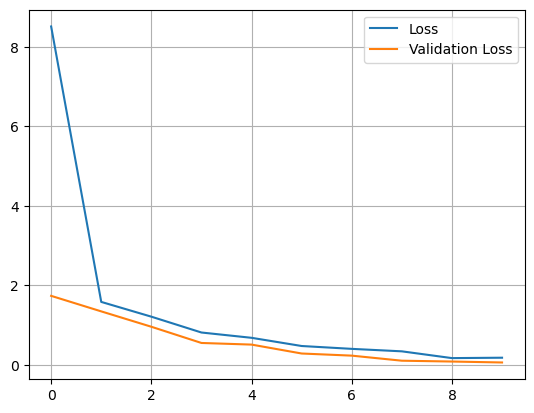

In [3]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [4]:
score = model.evaluate(test_dataset, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2025-04-01 08:22:58.790389: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_92', 4 bytes spill stores, 4 bytes spill loads



Test loss: 0.07149426639080048
Test accuracy: 1.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step


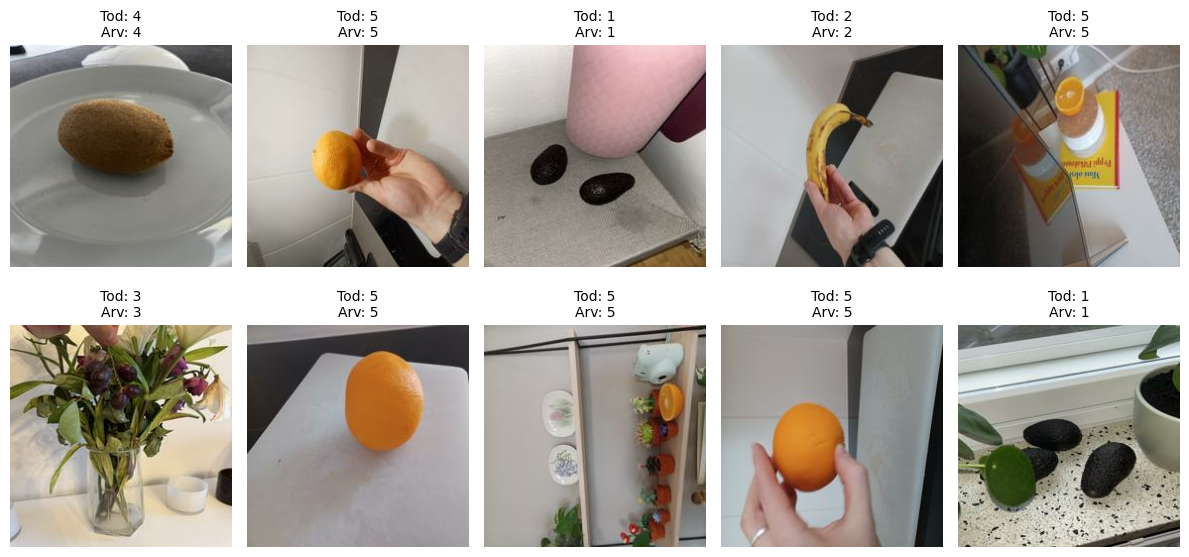

In [5]:
# Haetaan testidatasetista yksi batch
test_images, test_labels = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions = model.predict(test_images)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels = np.argmax(test_labels, axis=1)
predicted_labels = np.argmax(predictions, axis=1)

# Plottataan 10 ensimmäistä kuvaa
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow((test_images[i].numpy() * 255).astype("uint8"))  
    plt.axis("off")

    # Näytetään oikea ja ennustettu luokka
    plt.title(f"Tod: {true_labels[i]}\nArv: {predicted_labels[i]}", fontsize=10)

plt.tight_layout()
plt.show()

# Kuvantunnistus omilla kuvilla - VGG16 Assisted

In [6]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D


# Load pre-trained VGG16 model without the top layer
vgg16_base = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

vgg16_base.trainable = False

# Create new model on top
x = vgg16_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(6, activation='softmax')(x)

# Create final model
model2 = Model(inputs=vgg16_base.input, outputs=predictions)

# Compile the model
model2.compile(optimizer='adam', 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

history2 = model2.fit(train_dataset, validation_data=validation_dataset, epochs=10)

Epoch 1/10


2025-04-01 08:23:02.452170: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_634', 188 bytes spill stores, 188 bytes spill loads

2025-04-01 08:23:02.917268: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1511', 36 bytes spill stores, 44 bytes spill loads

2025-04-01 08:23:03.047648: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1511', 32 bytes spill stores, 32 bytes spill loads

2025-04-01 08:23:03.482829: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1511', 56 bytes spill stores, 56 bytes spill loads



 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.1773 - loss: 2.0869

2025-04-01 08:23:10.088118: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_234', 4 bytes spill stores, 4 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.1956 - loss: 2.0520 - val_accuracy: 0.3594 - val_loss: 1.4321
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4124 - loss: 1.5494 - val_accuracy: 0.5625 - val_loss: 1.3008
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5633 - loss: 1.3095 - val_accuracy: 0.7031 - val_loss: 1.0668
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6176 - loss: 1.1296 - val_accuracy: 0.6250 - val_loss: 1.0579
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.6009 - loss: 1.0940 - val_accuracy: 0.9062 - val_loss: 0.7472
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7355 - loss: 0.9363 - val_accuracy: 0.7656 - val_loss: 0.8743
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7354 - loss: 0.8716 - val_accuracy: 0.8906 - val_loss: 0.7067
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.7212 - loss: 0.8476 - val_accuracy: 0.8438 - val_loss: 

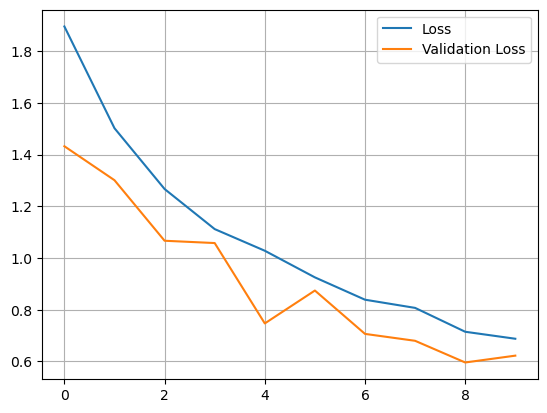

In [7]:
plt.plot(history2.history["loss"], label="Loss")
plt.plot(history2.history["val_loss"], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()

In [8]:
model2_test_score = model2.evaluate(test_dataset, verbose=0)
print('Test loss:', model2_test_score[0])
print('Test accuracy:', model2_test_score[1])

2025-04-01 08:23:17.540358: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 200 bytes spill stores, 200 bytes spill loads

2025-04-01 08:23:17.602795: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_227', 4 bytes spill stores, 4 bytes spill loads

2025-04-01 08:23:17.671968: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_234', 4 bytes spill stores, 4 bytes spill loads



Test loss: 0.5844854712486267
Test accuracy: 0.8829787373542786


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 842ms/step


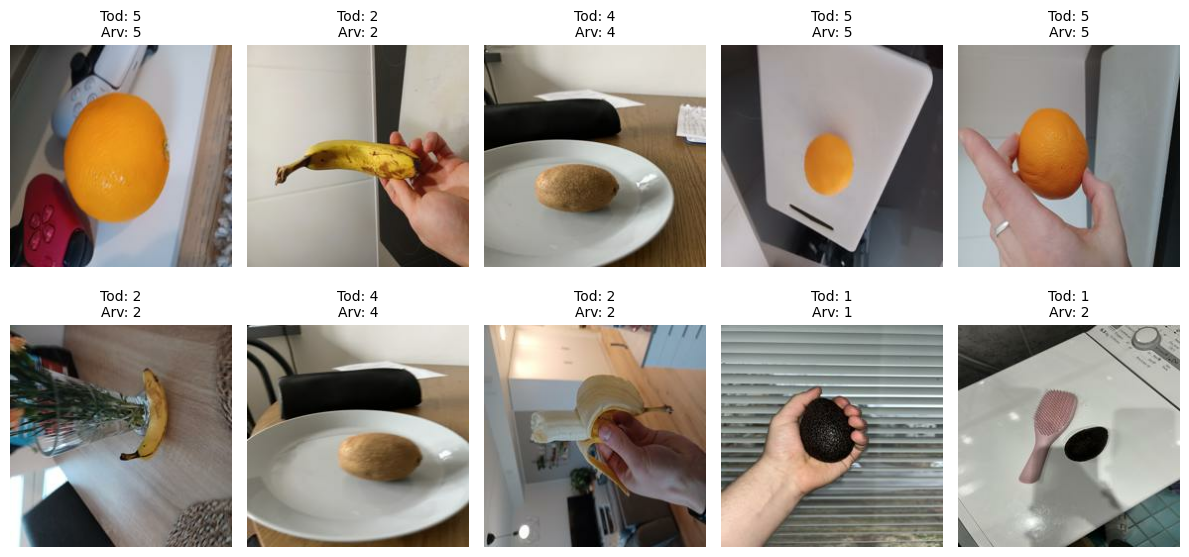

In [9]:
# Haetaan testidatasetista yksi batch
test_images2, test_labels2 = next(iter(test_dataset.take(1)))

# Ennustetaan mallilla
predictions2 = model2.predict(test_images2)

# Muunnetaan one-hot-enkoodatut labelit kokonaisluvuiksi
true_labels2 = np.argmax(test_labels2, axis=1)
predicted_labels2 = np.argmax(predictions2, axis=1)

# Plotataan 10 ensimmäistä kuvaa
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow((test_images2[i].numpy() * 255).astype("uint8"))  
    plt.axis("off")

    # Näytetään oikea ja ennustettu luokka
    plt.title(f"Tod: {true_labels2[i]}\nArv: {predicted_labels2[i]}", fontsize=10)
    
plt.tight_layout()
plt.show()